In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
class Datalogger_Processing:
    def __init__(self, filepath):
      '''
      Class for processing datalogger files

      Arg:
        filepath: string of filepath to datalogger CSV
      '''
      self.fp = filepath

      self.fp_string = self.fp.split('/')[-1]

      self.df = pd.read_csv(self.fp)


    def subplots(self, xaxis='Timer[S]', title=None):
      '''
      Method for subplots of datalogger data

      Args:
        Columns
      '''
      if title is None:
          title = self.fp_string

      fig1, axes = plt.subplots(1, 3, figsize=(20, 5))

      axes[0].plot(self.df[xaxis], self.df['Events CW1&2'], marker='o', markersize=0.7, color='blue', label="CW 1 & 2")
      axes[0].plot(self.df[xaxis], self.df['Events CW1&2&3'], marker='o', markersize=0.7, color='magenta', label="CW 1 & 2 & 3")
      axes[0].set_xlabel(xaxis)
      axes[0].set_ylabel('Events')
      axes[0].legend()
      axes[0].set_title('CosmicWatch Events over Time')

      axes[1].plot(self.df[xaxis], self.df['Pressure[Pa]'], marker='o', markersize=0.7, color='green', label="Pressure")
      axes[1].set_xlabel(xaxis)
      axes[1].set_ylabel('Pressure[Pa]')
      axes[1].legend()
      axes[1].set_title('Pressure over Time')

      axes[2].plot(self.df[xaxis], self.df['Temperature[C]'], marker='o', markersize=0.7, color='red', label="Temperature")
      axes[2].set_xlabel(xaxis)
      axes[2].set_ylabel('Temperature[C]')
      axes[2].legend()
      axes[2].set_title('Temperature over Time')

      plt.suptitle(title)
      plt.show()

    def separate_timer_resets(self, plotting_title=None):
      '''
      Detect any timer resets in the datalogger data, and creates separate DataFrames for each run. Then creates an Absolute Timer column to add to the dataframe, and plots the data as a function of the absolute timer.
      '''
      if plotting_title is None:
          plotting_title = self.fp_string

      self.df_sorted = self.df.copy().sort_index().reset_index(drop=True)                      # make sure rows are in original order + give clean 0-based index

      time_col = 'Timer[S]'                                                    # name of the column that holds the timer values

      reset_mask = self.df_sorted[time_col].diff() < -10                                # .diff() computes row-to-row differences; this creates a boolean mask that's True wherever the time decreased by more than 3 seconds (negative value indicates a reset/jump backward)

      new_segment_starts = [0] + (reset_mask[reset_mask].index).tolist()   # list of row numbers where each new segment begins: 0 + (index of each True + 1 to point to first row of next segment)
      print(f"Detected {len(new_segment_starts)-1} separate timer reset(s) at rows {new_segment_starts}")

      self.timerreset_segments = []                                                            # empty list that will store one DataFrame per continuous run

      for i in range(len(new_segment_starts)):                                 # loop over each detected starting point
        start = new_segment_starts[i]                                        # determine starting row index of current segment; store in "start"
        end = new_segment_starts[i+1] if i+1 < len(new_segment_starts) else None   # ending row = start of next segment, or None (means go to end of DataFrame)
        seg = self.df_sorted.iloc[start:end].copy()                                  # slice out this segment and make independent copy; iloc
        seg['Timer_rel'] = seg[time_col] - seg[time_col].iloc[0]             # add relative time column that starts at ~0 for this run
        self.timerreset_segments.append(seg)                                                 # store this segment in the list

      for i, seg in enumerate(self.timerreset_segments, 1):
        t_min = seg[time_col].min()
        t_max = seg[time_col].max()
        nrows = len(seg)
        print(f"  Run {i:2d}: {nrows:5d} rows, timer {t_min:6.0f} → {t_max:6.0f} s")

      self.create_absolute_timer()

      for i, start_idx in enumerate(new_segment_starts):
        print(f"\n--- Around start of Timer Reset {i+1} (row {start_idx}) ---")

        start = max(0, start_idx - 5)
        end   = start_idx + 6

        slice_df = self.df.iloc[start:end] # Changed from self.df_sorted to self.df

        print(slice_df[[time_col, 'Events CW1&2', 'Events CW1&2&3', 'Absolute Timer (S)']].to_string(index=True))

      self.subplots(xaxis='Absolute Timer (S)', title=plotting_title)


    def create_absolute_timer(self):
      '''
      Creates continuous Absolute Timer by chaining last value from before timer reset
      '''
      absolute_timers = []
      previous_end = 0.0

      for i, seg in enumerate(self.timerreset_segments):
        current_timers = seg['Timer[S]'].values

        if len(current_timers) == 0:
            continue

        absolute_this_segment = current_timers + previous_end

        absolute_timers.extend(absolute_this_segment)

        previous_end = absolute_this_segment[-1]

      self.df['Absolute Timer (S)'] = absolute_timers

## 0 Degrees Datalogger

In [4]:
datalogger_csv_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_DATALOGGER.csv' # @param {type:"string"}
top_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_TOP.txt' # @param {type:"string"}
mid_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_MID.txt' # @param {type:"string"}
bot_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_BOT.txt' # @param {type:"string"}

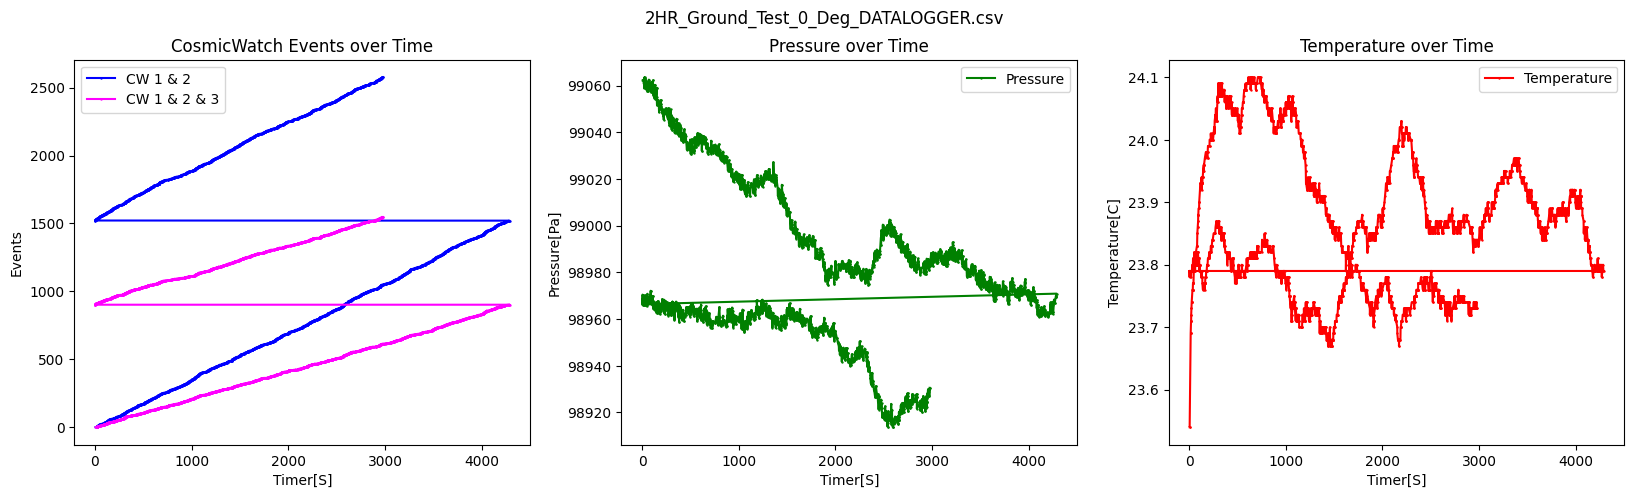

Detected 1 separate timer reset(s) at rows [0, 2423]
  Run  1:  2423 rows, timer      6 →   4289 s
  Run  2:  1702 rows, timer      2 →   2975 s

--- Around start of Timer Reset 1 (row 0) ---
    Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
0   5.849609             1               0            5.849609
1   5.855468             1               1            5.855468
2  16.342773             2               1           16.342773
3  16.415039             3               1           16.415039
4  16.420898             3               2           16.420898
5  19.281250             4               2           19.281250

--- Around start of Timer Reset 2 (row 2423) ---
         Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
2418  4269.168945          1518             901         4269.168945
2419  4281.617187          1519             901         4281.617187
2420  4286.391601          1520             901         4286.391601
2421  4286.411132          1520             9

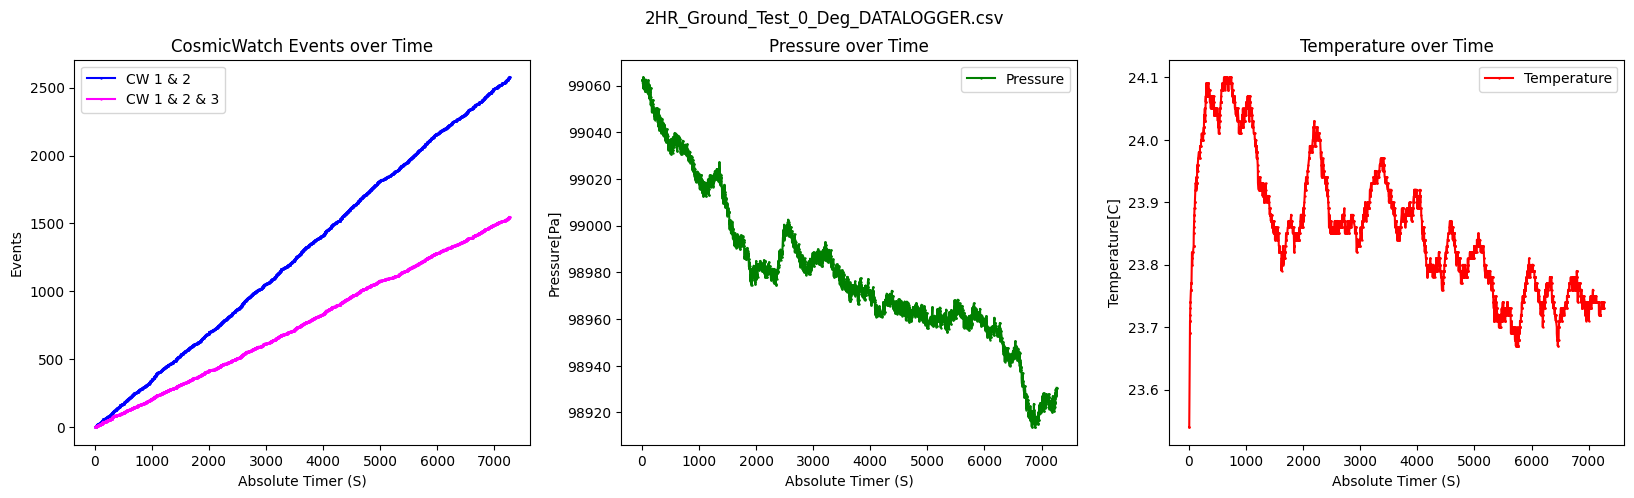

In [5]:
Datalogger_Processing(datalogger_csv_fp).subplots()
Datalogger_Processing(datalogger_csv_fp).separate_timer_resets()
# Datalogger csv as pandas dataframe
datalogger_df = Datalogger_Processing(datalogger_csv_fp).df

The datalogger file contains coincidence events across CosmicWatches 1&2, and 1, 2 & 3 along with the time stamps for all coincidence events. However, the scintillator files for each individual CosmicWatch contain data with a timestamp of any time that individual CosmicWatch scintillated. We are interested in the signal in mV on each individual scintillator at the point in time where there was three scintillator coincidence. In other words, we want to see the SiPM signal, in mV, for each scintillator (located in the files for each scintillator) ONLY at the time stamps where there was three-scintillator coincidence, indicating a pure muon sample.

In [14]:
class Scintillator_Processing:
    def __init__(self, filepaths):
      '''
      Class for processing scintillator files

      Arg:
        filepaths: list of filepath strings for each scintillator TXT
      '''
      self.fps = filepaths

      columns = ['Event','Time[s]','Coincident[bool]','ADC[0-4095]','SiPM[mV]','Deadtime[s]','Temp[C]','Pressure[Pa]']

      for i, fp in enumerate(filepaths, start=1):
            df = pd.read_csv(fp, sep='\t', comment='#', header=None, skiprows=3, names=columns, engine='python')
            setattr(self, f'scint_{i}', df)

    def plot_all_scintillators(self, datalogger_df_raw):
      self.align_with_datalogger(datalogger_df_raw)  # once, not per scintillator

      for i in range(1, len(self.fps) + 1):
          self.plot_CoincidenceRates_vs_SiPMVoltage(i)  # no scint_df or datalogger arg needed

      colors = ['blue', 'orange', 'green', 'red', 'purple']
      fig, ax = plt.subplots(figsize=(8, 4))
      for i in range(1, len(self.fps) + 1):
          cw123_data = self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna()
          print(f"\nScintillator {i} — SiPM_mV_CW123 stats:")
          print(f"  Non-null count: {len(cw123_data)}")
          print(f"  Min: {cw123_data.min():.2f} mV, Max: {cw123_data.max():.2f} mV, Mean: {cw123_data.mean():.2f} mV")
          ax.hist(cw123_data, bins=100,
                  color=colors[(i-1) % len(colors)], edgecolor='black',
                  alpha=0.5, label=f'Scintillator {i}')
      ax.set_xlabel('SiPM[mV]', fontsize=12)
      ax.set_ylabel('Count', fontsize=12)
      ax.set_title('SiPM Voltage Distribution — All Scintillators', fontsize=12)
      ax.set_yscale('log')
      ax.legend(fontsize=11)
      plt.tight_layout()
      plt.show()

    def plot_CoincidenceRates_vs_SiPMVoltage(self, i):
        binned = getattr(self, f'binned_and_aligned_df_{i}')

        fig, (ax, ax3) = plt.subplots(1, 2, figsize=(16, 6))

        ax.errorbar(binned['mean_mV'], binned['mean_rate_12'],
              yerr=binned['err_12'], fmt='o-', color='darkorange',
              lw=1.5, markersize=4, label='CW 1+2 Coincident Rate', capsize=3)
        ax.errorbar(binned['mean_mV'], binned['mean_rate_123'],
                    yerr=binned['err_123'], fmt='o-', color='steelblue',
                    lw=1.5, markersize=4, label='CW 1+2+3 Coincident Rate', capsize=3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(f'SiPM Peak Voltage [mV] (Scintillator {i})', fontsize=13)
        ax.set_ylabel(r'Mean Count Rate [s$^{-1}$]', fontsize=13)
        ax.set_title(f'CW Coincident Rate vs. Scintillator {i} SiPM Voltage\n(0° Ground Test — Timestamp Aligned, Log-Log)', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, which='both', linestyle='--', alpha=0.4)

        ax3.hist(self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna(), bins=100, color='blue', edgecolor='black')
        ax3.set_xlabel('SiPM[mV]', fontsize=12)
        ax3.set_ylabel('Count', fontsize=12)
        ax3.set_title(f'SiPM Voltage Distribution for Scintillator {i}\n(Triple Coincidence Events Only)', fontsize=12)
        ax3.set_yscale('log')

        plt.tight_layout()
        plt.show()

      # fig2, ax2 = plt.subplots(figsize=(8, 4))
      # ax2.hist(aligned['dt_match[s]'].dropna(), bins=100, color='gray', edgecolor='black')
      # ax2.set_xlabel('Timestamp Match Offset [s]', fontsize=12)
      # ax2.set_ylabel('Count', fontsize=12)
      # ax2.set_title('Diagnostic: Timestamp Match Offsets (should peak near 0 because most timestamps between datalogger and scintillator files \n should be very close; should be very few large time offsets)', fontsize=12)
      # ax2.set_yscale('log')
      # plt.tight_layout()
      # plt.show()

    def align_with_datalogger(self, datalogger_df_raw, NUM_BINS=50):
      '''
      Create a new dataframe that has all the rows from datalogger plus adds the corresponding columns from the given scintillator where they have
      close enough timestamp matches, with NaN in fields where there was not a close enough time match.


      Result:
          self.aligned_df : dataframe with only data from the specified scintillator at the points where all three were in coincidence
          self.binned_and_aligned_df: dataframe with column headers "mV_bin", "mean_mV", "mean_rate_12", "mean_rate_123", "n_events", "err_12", "err_123" which are the SiPM bin edges, mean SiPM values, mean cosmic watch rates, and number of rows / events per bin
      '''
      dl_df = datalogger_df_raw.sort_values('Timer[S]').reset_index(drop=True)
      aligned = dl_df.copy()

      # looping through each of the provided scintillator files
      for i in range(1, len(self.fps) + 1):
          scint_df = getattr(self, f'scint_{i}')[['Time[s]','SiPM[mV]','ADC[0-4095]','Coincident[bool]']].copy() # defining the scintillator dataframe for each iteration to be the ith scintillator attribute; taking the specified columns from those files
          # renaming columns to combine into one large dataframe with datalogger
          scint_df = scint_df.rename(columns={
              'Time[s]':        f'Time_scint{i}[s]',
              'SiPM[mV]':       f'SiPM_scint{i}[mV]',
              'ADC[0-4095]':    f'ADC_scint{i}[0-4095]',
              'Coincident[bool]': f'Coincident_scint{i}[bool]'
          }).sort_values(f'Time_scint{i}[s]').reset_index(drop=True)

          # pd.merge_asof(...) merges rows based on the closest matching value in a sorted key column (usually time); “For each row in dl_df, find the closest time in scint_df and join them.”
          # creating new dataframe that has all the rows from dl_df PLUS adds the corresponding columns from scint_df where it has a close enough time match within the "Time_top[s]" column to the values in the "Timer[s]" of dl_df
          # puts NaN in fields where there was not a close enough time match
          aligned = pd.merge_asof(
              aligned, scint_df, # datalogger dataframe (aligned = dl_df.copy) is copied as the main dataframe in the new version
              left_on='Timer[S]', # left_on and right_on specify which columns to match on from the left DataFrame (dl_df['Timer[S]']) and the right DataFrame (scint_df['Time_top[s]'])
              right_on=f'Time_scint{i}[s]',
              direction='nearest', # performs a nearest-neighbor join, meaning for each row in dl_df, it finds the closest matching time in scint_df within a tolerance of 5.0 seconds
              tolerance=5.0
          )

      print(f"Aligned/combined dataframe headers {aligned.columns}")

      n_matched = aligned['SiPM[mV]'].notna().sum() # finding number of entries in the new dataframe where the time in the datalogger / the time where all three had coincidence was the same ()
      n_total   = len(aligned)
      print(f"Matched: {n_matched} / {n_total} rows")
      print(f"Unmatched: {n_total - n_matched} rows")

      aligned['dt_match[s]'] = (aligned['Timer[S]'] - aligned['Time_top[s]']).abs() # adding a column to the aligned dataframe that states the offset in matching times
      print(f"\nMatch offset stats (seconds):")
      print(aligned['dt_match[s]'].describe().round(4))

      # Each row is added in datalogger file corresponds to a time where either both CW 1 & 2 detected a particle, or every time CW 1, 2 & 3 detected particles
      # numbers in the Events CW1&2 and the Events CW1&2&3 columns are the total cumulative events up until that time point
      aligned['delta_CW12']  = aligned['Events CW1&2'].diff().clip(lower=0).fillna(0) # adding a column that states the difference in CW1&2 coincidence events between consecutive rows i.e., how much the coincidence event count increases for CW 1 & 2 between each time stamp
      aligned['delta_CW123'] = aligned['Events CW1&2&3'].diff().clip(lower=0).fillna(0) # adding a column that states the difference in CW1&2&3 coincidence events between consecutive rows i.e., how much the coincidence event count increases for CW 1 & 2 & 3 between each time stamp
      aligned['delta_t']     = aligned['Timer[S]'].diff().clip(lower=0).fillna(0)
      aligned['rate_CW12']  = np.where(aligned['delta_t'] > 0, aligned['delta_CW12']  / aligned['delta_t'], np.nan) # adding column that states the scintillation rate in each time step (divide delta_CW count by delta_t)
      aligned['rate_CW123'] = np.where(aligned['delta_t'] > 0, aligned['delta_CW123'] / aligned['delta_t'], np.nan)

      for i in range(1, len(self.fps) + 1):
        aligned[f'SiPM_mV_CW123_scint{i}'] = aligned[f'SiPM_scint{i}[mV]'].where(aligned['delta_CW123'] > 0)

      self.aligned_df = aligned.copy()

      for i in range(1, len(self.fps) + 1):
          plot_df = aligned[aligned['delta_CW123'] > 0].dropna(subset=[f'SiPM_scint{i}[mV]','rate_CW12','rate_CW123']).copy()
          print(f"\nScint {i} rows for plotting: {len(plot_df)}")

          sipm_min  = max(aligned[f'SiPM_mV_CW123_scint{i}'].dropna().min(), 0.1)
          sipm_max  = aligned[f'SiPM_mV_CW123_scint{i}'].dropna().max()
          bin_edges = np.logspace(np.log10(sipm_min), np.log10(sipm_max), NUM_BINS + 1)

          plot_df['mV_bin'] = pd.cut(plot_df[f'SiPM_scint{i}[mV]'], bins=bin_edges, include_lowest=True)

          binned = plot_df.groupby('mV_bin', observed=True).agg(
              mean_mV       = (f'SiPM_scint{i}[mV]', 'mean'),
              mean_rate_12  = ('rate_CW12',           'mean'),
              mean_rate_123 = ('rate_CW123',          'mean'),
              n_events      = (f'SiPM_scint{i}[mV]', 'count'),
          ).reset_index()

          binned['err_12']  = binned['mean_rate_12']  / np.sqrt(binned['n_events'].clip(lower=1))
          binned['err_123'] = binned['mean_rate_123'] / np.sqrt(binned['n_events'].clip(lower=1))
          binned = binned.dropna(subset=['mean_mV'])
          setattr(self, f'binned_and_aligned_df_{i}', binned.copy())

1
Datalogger headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]'],
      dtype='object')
Scint headers Index(['Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'], dtype='object')
Aligned/combined dataframe headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]',
       'Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'],
      dtype='object')
Matched: 4125 / 4125 rows
Unmatched: 0 rows

Match offset stats (seconds):
count    4125.0000
mean        0.2703
std         0.2716
min

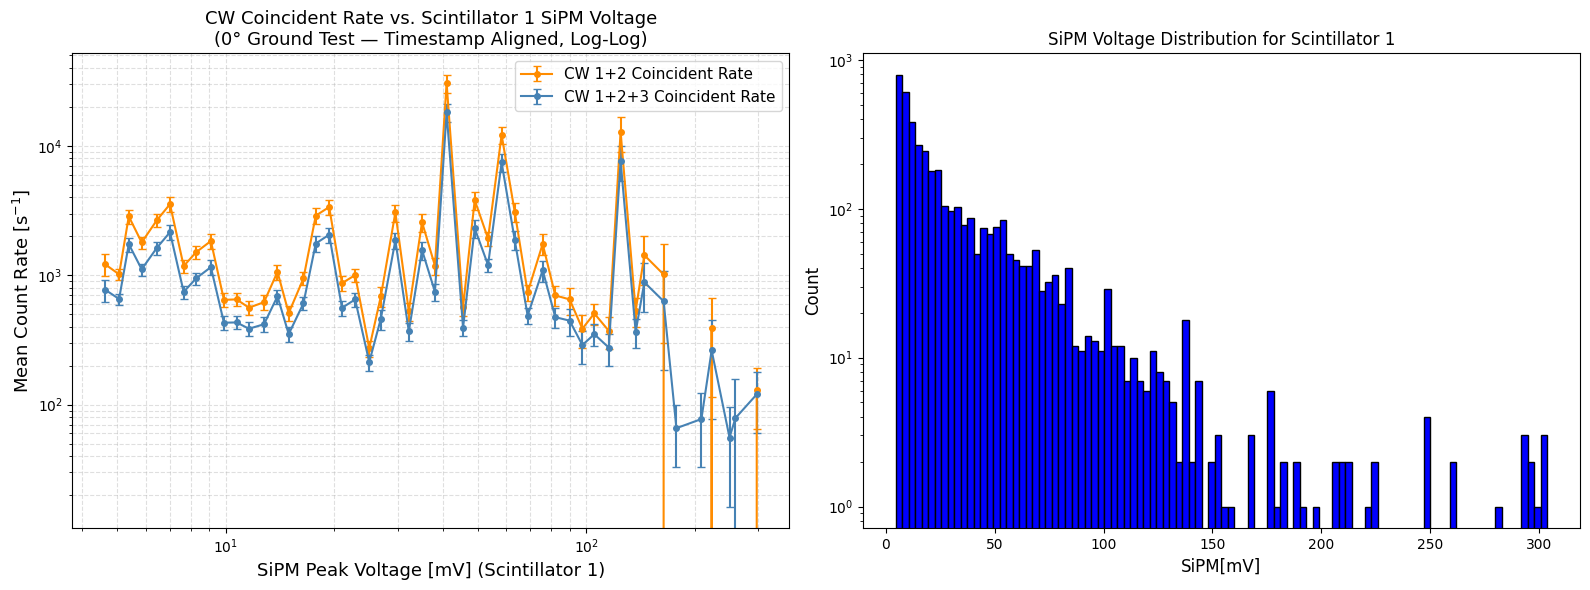

2
Datalogger headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]'],
      dtype='object')
Scint headers Index(['Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'], dtype='object')
Aligned/combined dataframe headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]',
       'Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'],
      dtype='object')
Matched: 4125 / 4125 rows
Unmatched: 0 rows

Match offset stats (seconds):
count    4125.0000
mean        0.2591
std         0.2573
min

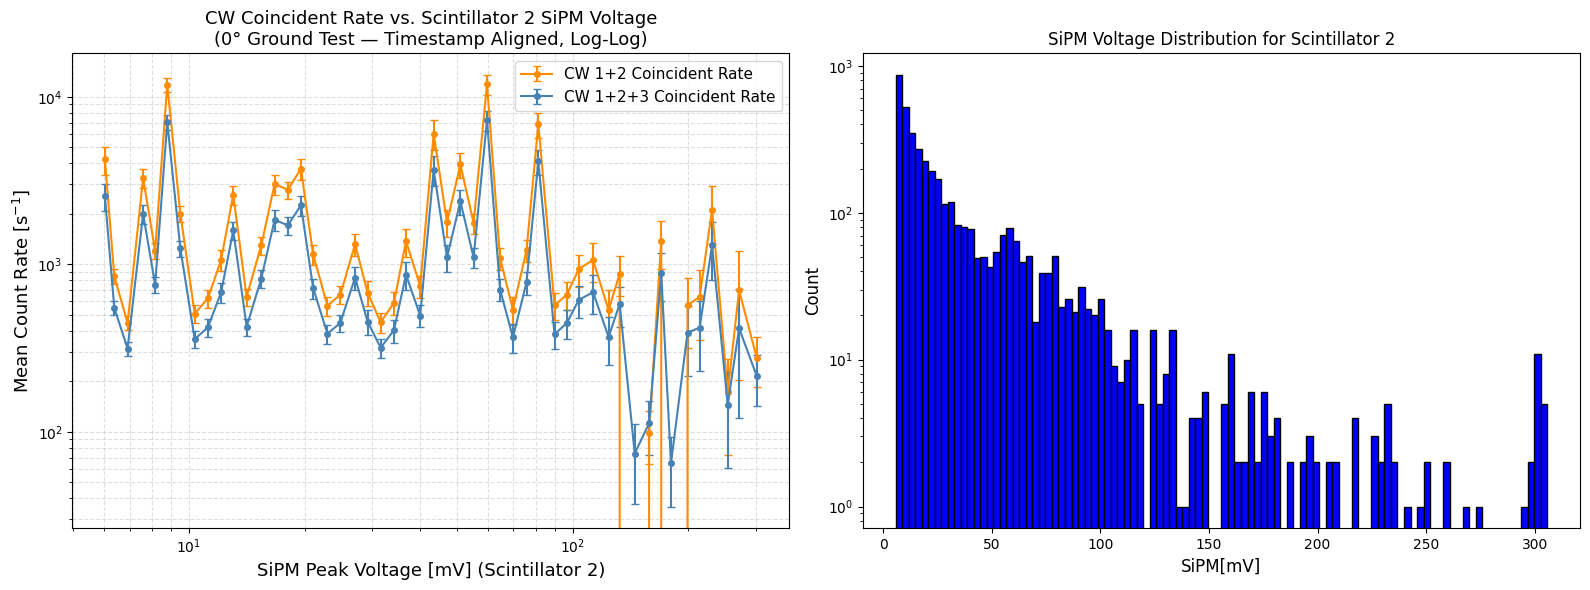

3
Datalogger headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]'],
      dtype='object')
Scint headers Index(['Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'], dtype='object')
Aligned/combined dataframe headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]',
       'Time_top[s]', 'SiPM[mV]', 'ADC[0-4095]', 'Coincident[bool]'],
      dtype='object')
Matched: 4125 / 4125 rows
Unmatched: 0 rows

Match offset stats (seconds):
count    4125.0000
mean        0.2822
std         0.2793
min

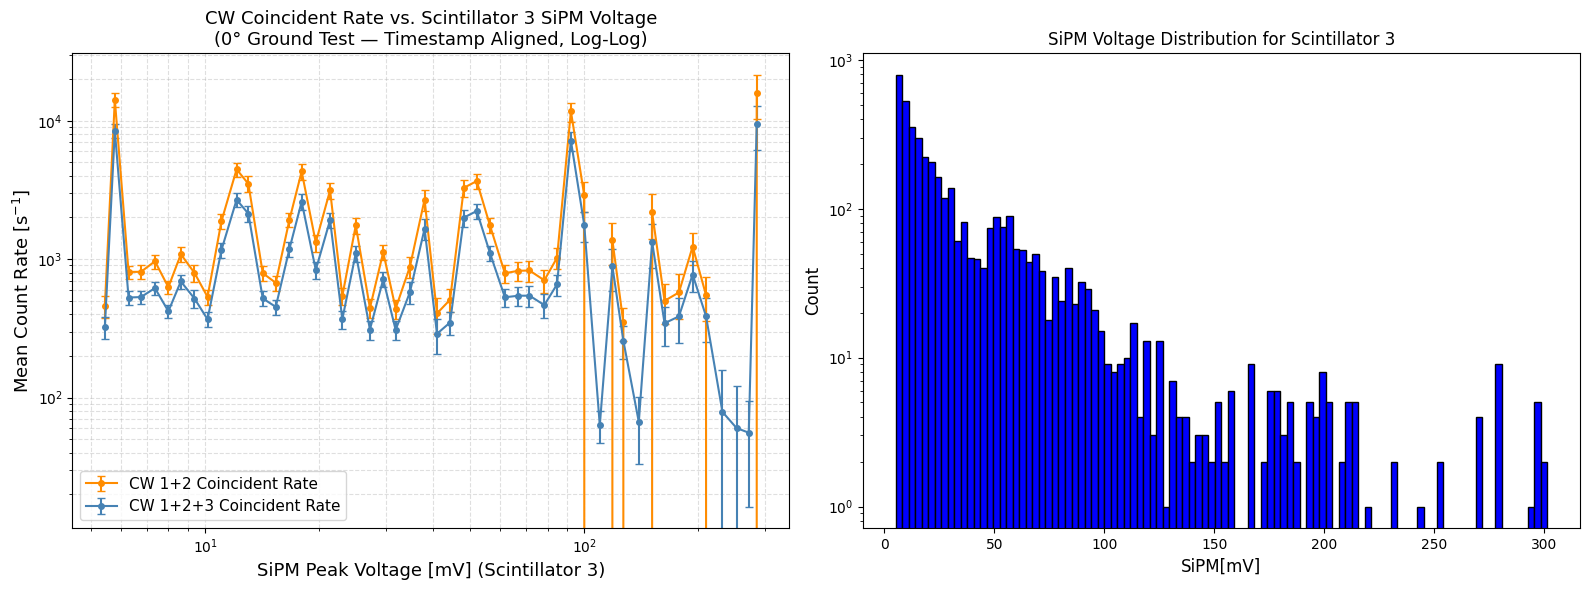


Scintillator 1 — SiPM_mV_CW123 stats:
  Non-null count: 2071
  Min: 4.40 mV, Max: 303.90 mV, Mean: 29.18 mV

Scintillator 2 — SiPM_mV_CW123 stats:
  Non-null count: 2071
  Min: 5.70 mV, Max: 305.80 mV, Mean: 33.96 mV

Scintillator 3 — SiPM_mV_CW123 stats:
  Non-null count: 2071
  Min: 5.10 mV, Max: 301.50 mV, Mean: 33.63 mV


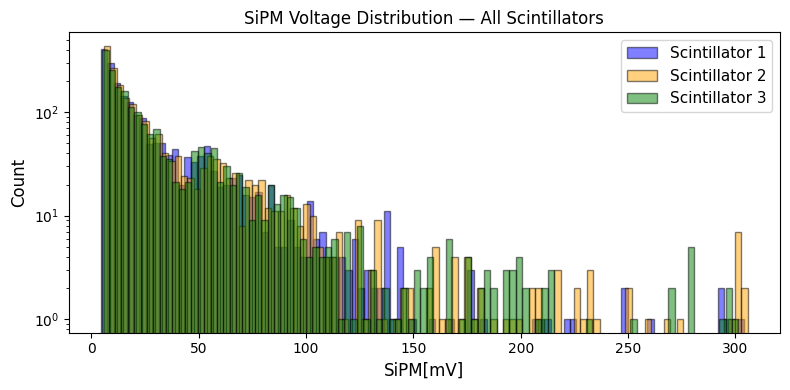

In [13]:
top_scintillator = Scintillator_Processing([top_scint_fp, mid_scint_fp, bot_scint_fp])
top_scintillator.plot_all_scintillators(datalogger_df)